In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path = r"D:\Thesis_Speed_Model\data\Raw\Data Final for Modeling with R1500.xlsx"
df = pd.read_excel(file_path)

In [3]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,1500,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,1500,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,1500,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16,5.5,0.9,Gravel,0.9,Gravel


In [4]:
df.shape

(140, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    140 non-null    int64  
 1   V85 Speed             140 non-null    float64
 2   Gradient              140 non-null    float64
 3   Radius of Curve       140 non-null    int64  
 4   Carriageway Width     140 non-null    float64
 5   Left Shoulder Width   140 non-null    float64
 6   Left Shoulder Type    140 non-null    str    
 7   Right Shoulder Width  140 non-null    float64
 8   Right Shoulder Type   140 non-null    str    
dtypes: float64(5), int64(2), str(2)
memory usage: 10.0 KB


In [6]:
df.isnull().sum()

SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder Width    0
Right Shoulder Type     0
dtype: int64

In [7]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,140.0000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,567.314286,6.257550,0.512214,0.521143
std,40.5586,10.353012,2.573637,668.940449,0.936458,0.401510,0.394580
min,1.0000,24.000000,0.100000,15.000000,4.700000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,50.000000,5.500000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,120.000000,7.000000,0.500000,0.500000
75%,105.2500,55.000000,5.985000,1500.000000,7.000000,0.900000,0.907500
max,140.0000,74.000000,10.000000,1500.000000,8.000000,1.130000,1.180000


In [8]:
num_cols = [
    "V85 Speed",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "Radius of Curve"
]

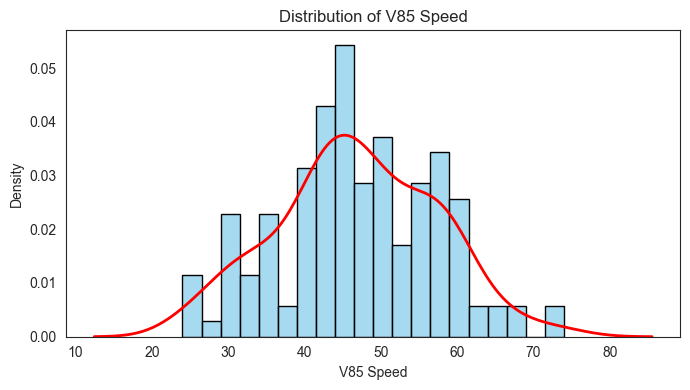

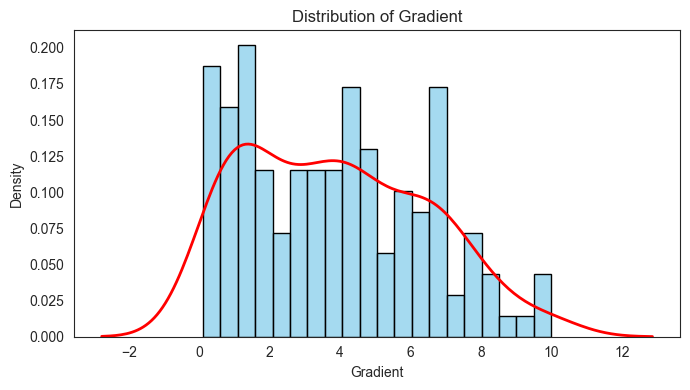

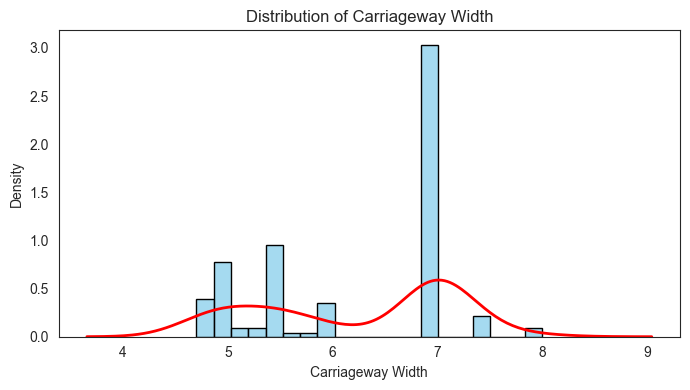

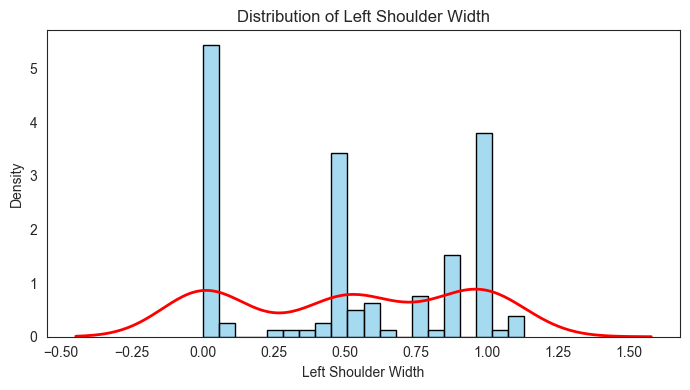

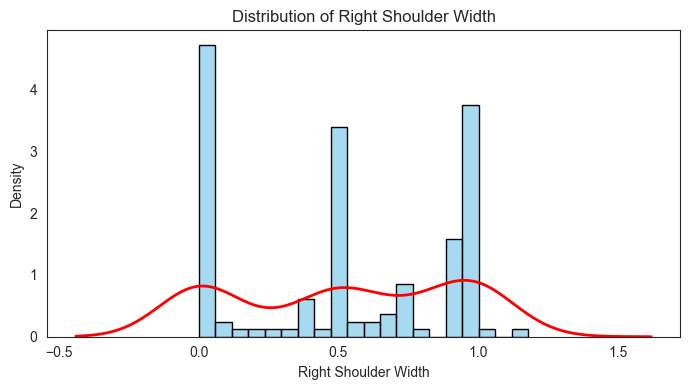

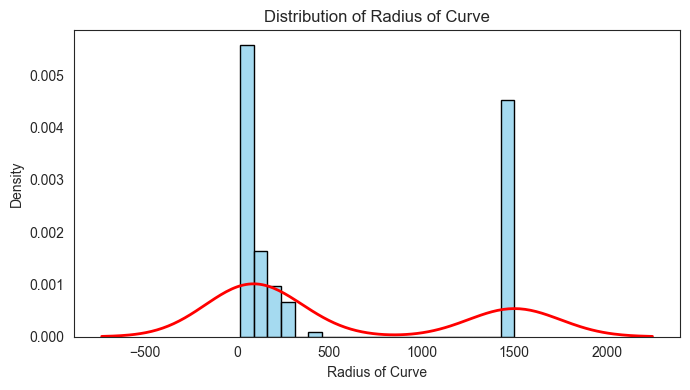

In [9]:
sns.set_style("white")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=20, stat="density", color="skyblue", edgecolor="black")
    sns.kdeplot(df[col], color="red", linewidth=2)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

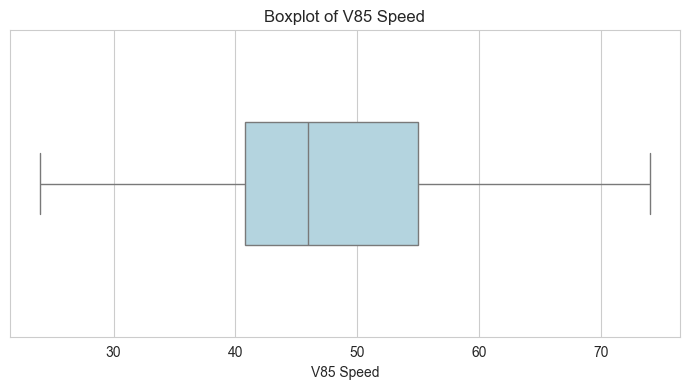

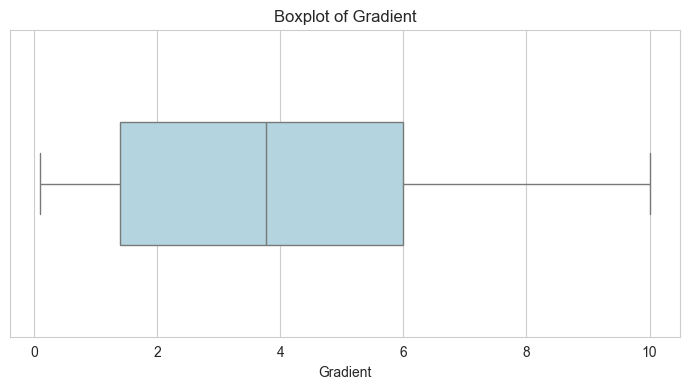

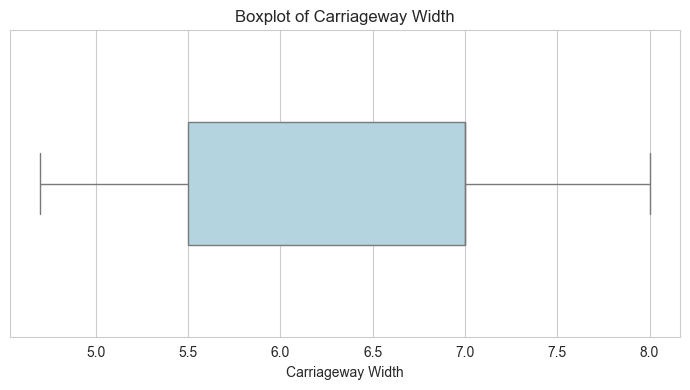

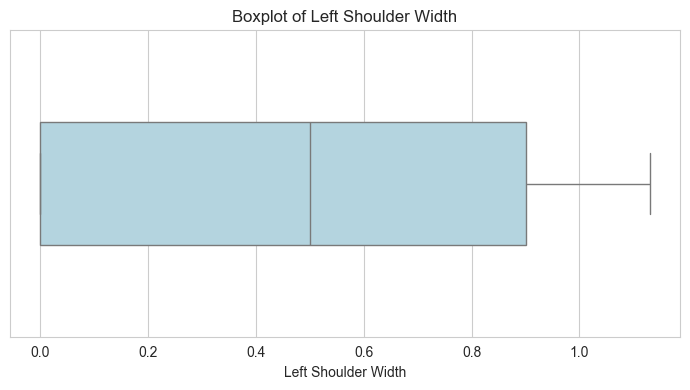

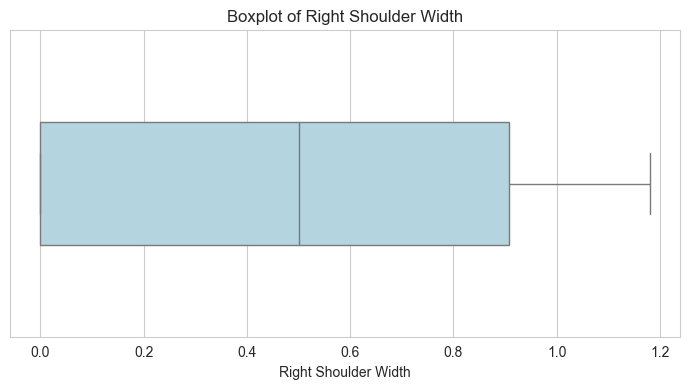

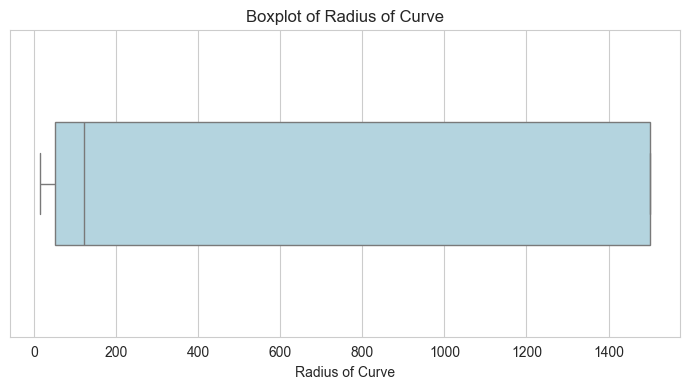

In [10]:
sns.set_style("whitegrid")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[col], color="lightblue", width=0.4)

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

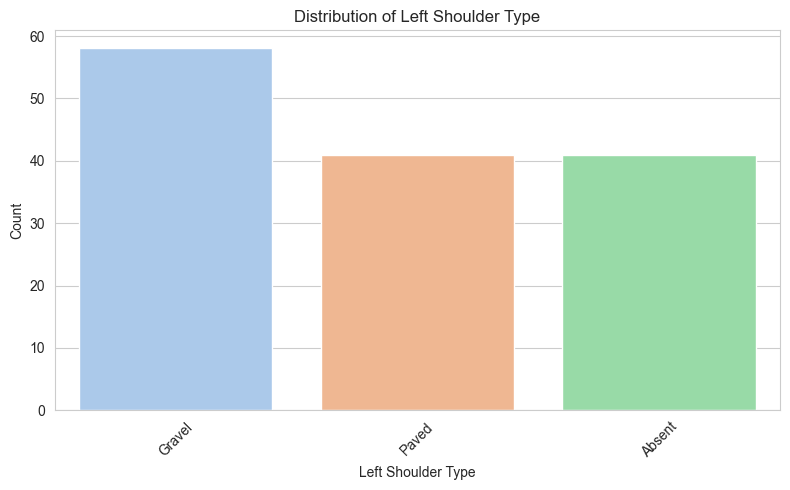

In [11]:
# Clean categorical values
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x=df["Left Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Left Shoulder Type")
plt.xlabel("Left Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

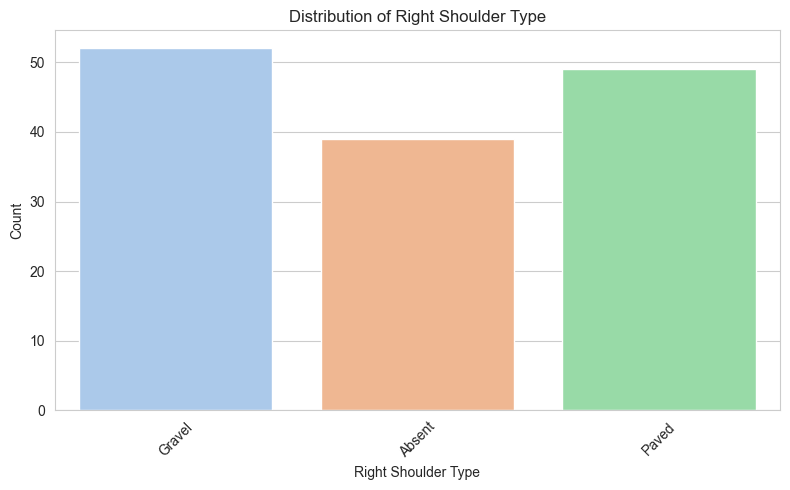

In [12]:
# Clean categorical values
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x=df["Right Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Right Shoulder Type")
plt.xlabel("Right Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

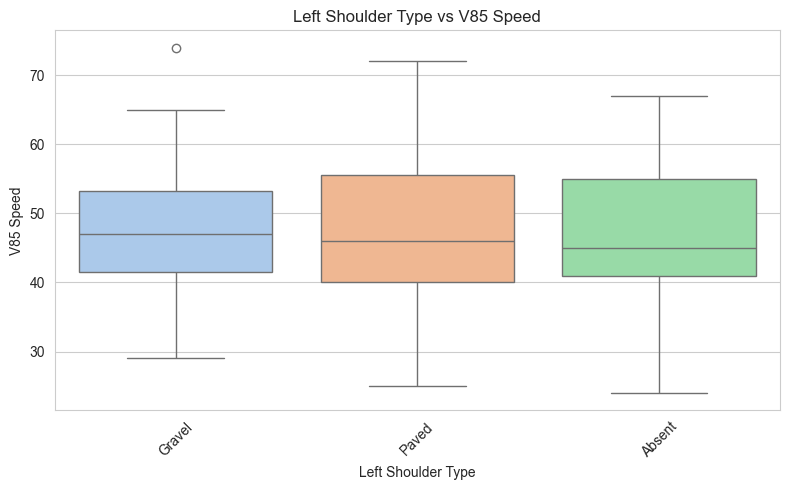

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Left Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Left Shoulder Type vs V85 Speed")
plt.xlabel("Left Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

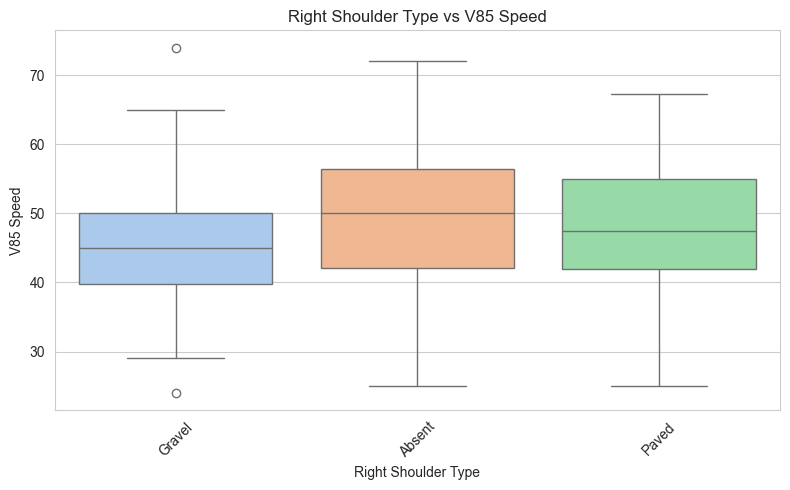

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Right Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Right Shoulder Type vs V85 Speed")
plt.xlabel("Right Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

In [15]:
df[num_cols].skew()

V85 Speed              -0.006374
Gradient                0.381686
Carriageway Width      -0.339377
Left Shoulder Width    -0.098318
Right Shoulder Width   -0.135425
Radius of Curve         0.671767
dtype: float64

In [16]:
skew_table = pd.DataFrame({
    "Variable": num_cols,
    "Skewness": df[num_cols].skew().values
})

skew_table

,Variable,Skewness
0,V85 Speed,-0.006374
1,Gradient,0.381686
2,Carriageway Width,-0.339377
3,Left Shoulder Width,-0.098318
4,Right Shoulder Width,-0.135425
5,Radius of Curve,0.671767


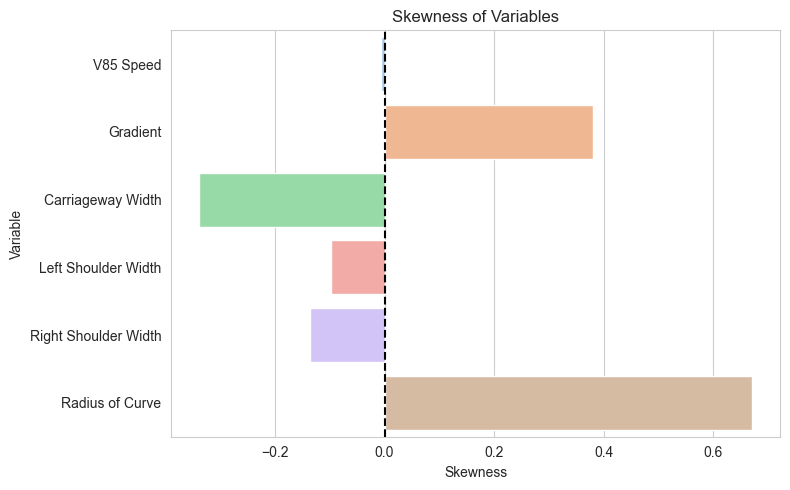

In [17]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x=skew_table["Skewness"], y=skew_table["Variable"], palette="pastel")

plt.axvline(0, color="black", linestyle="--")
plt.title("Skewness of Variables")
plt.xlabel("Skewness")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [18]:
corr_matrix = df[num_cols].corr()
corr_matrix

,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Radius of Curve
V85 Speed,1.000000,-0.014513,0.081495,0.025410,-0.039360,0.489553
Gradient,-0.014513,1.000000,-0.177301,-0.167458,-0.176552,-0.152652
Carriageway Width,0.081495,-0.177301,1.000000,0.032165,-0.207924,0.039981
Left Shoulder Width,0.025410,-0.167458,0.032165,1.000000,0.333377,0.142865
Right Shoulder Width,-0.039360,-0.176552,-0.207924,0.333377,1.000000,0.011811
Radius of Curve,0.489553,-0.152652,0.039981,0.142865,0.011811,1.000000


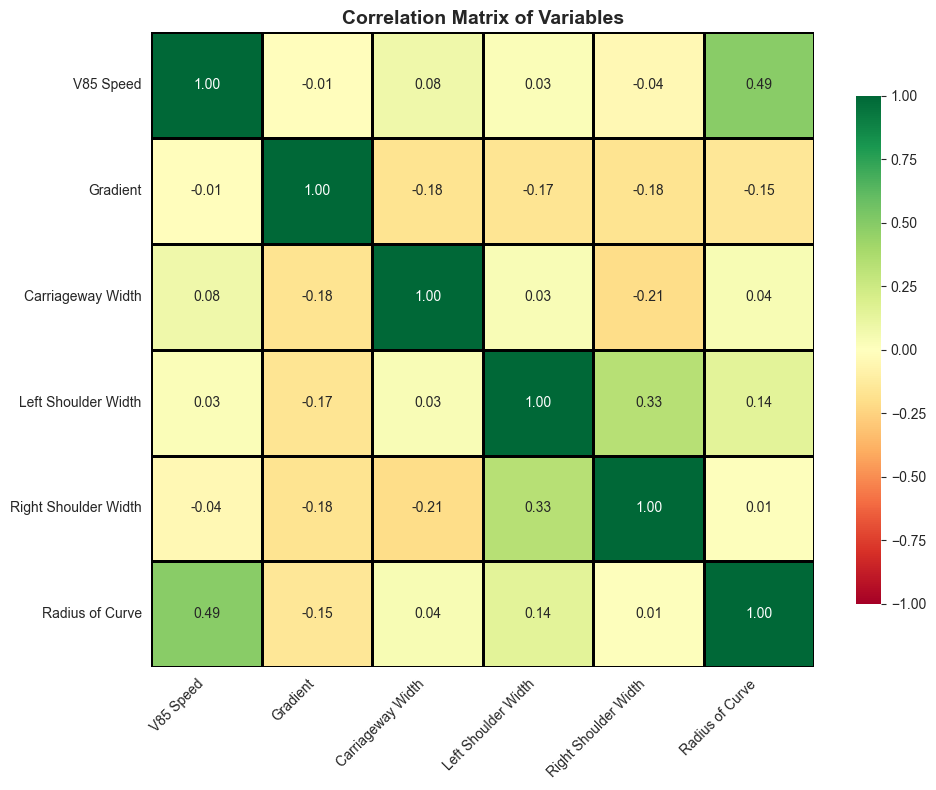

In [19]:
sns.set_style("white")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",        # your preferred colors
    vmin=-1, vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.8,
    linecolor="black",    # darker grid lines
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
predictor_cols = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

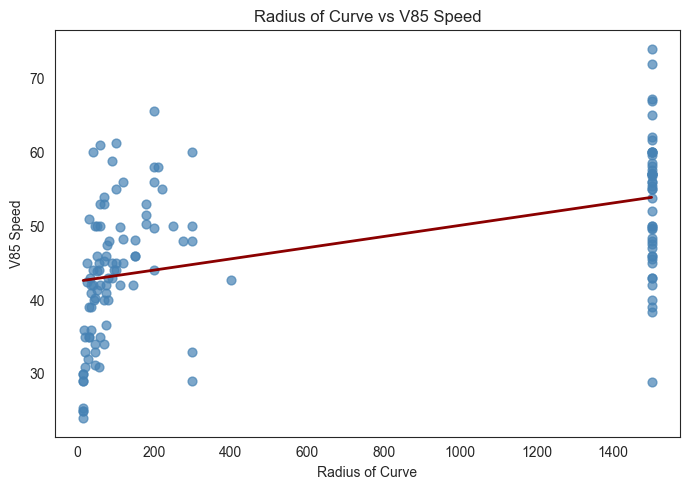

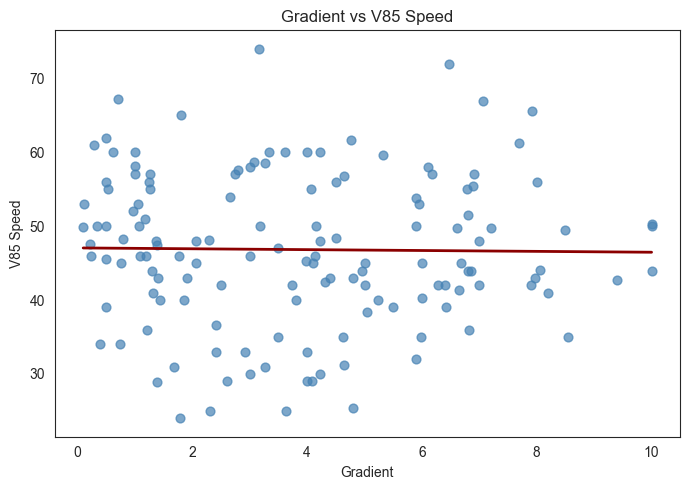

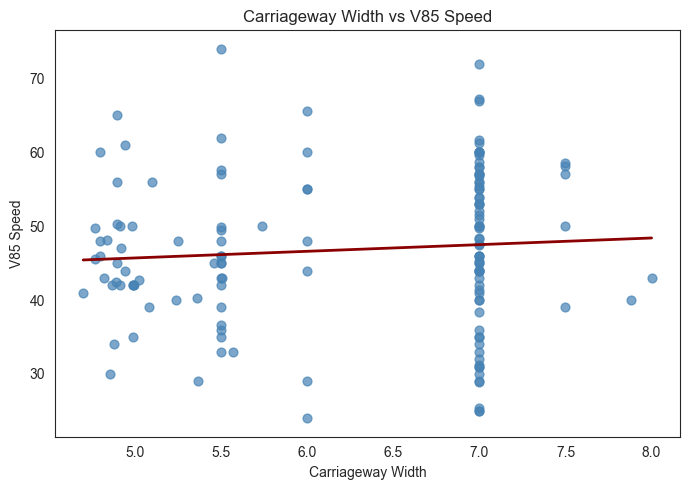

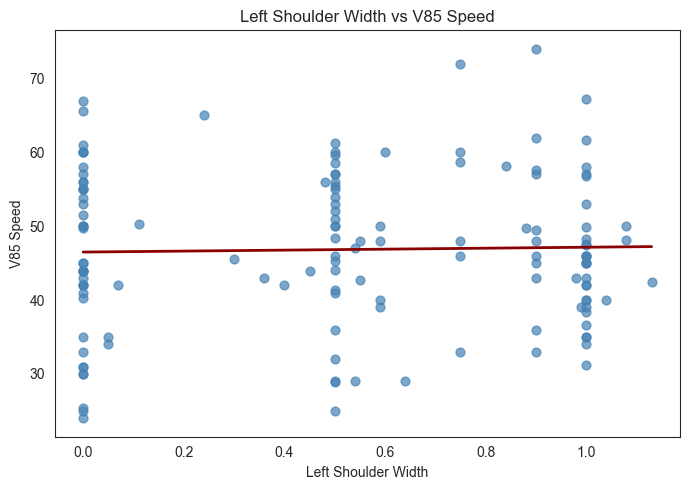

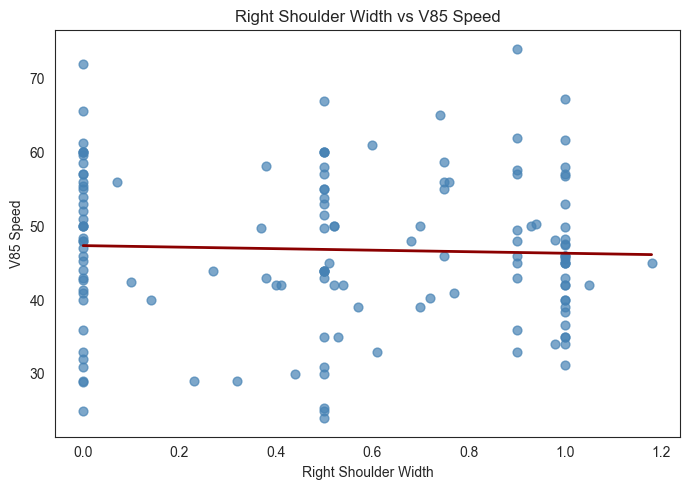

In [21]:
sns.set_style("white")

for col in predictor_cols:
    plt.figure(figsize=(7,5))   # same size for each plot

    sns.regplot(
        x=df[col],
        y=df["V85 Speed"],
        scatter_kws={"s":40, "color":"steelblue", "alpha":0.7},
        line_kws={"color":"darkred", "linewidth":2},
        ci=None   # no shaded region
    )

    plt.title(f"{col} vs V85 Speed")
    plt.xlabel(col)
    plt.ylabel("V85 Speed")

    plt.tight_layout()
    plt.show()

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True   # IMPORTANT to avoid dummy trap
)

In [23]:
X_vif = df_encoded[[
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
] + [col for col in df_encoded.columns if "Shoulder Type" in col]]

In [24]:
X_vif = X_vif.astype(float)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Feature,VIF
0,Radius of Curve,1.840867
1,Gradient,3.382350
2,Carriageway Width,9.064819
3,Left Shoulder Width,12.370477
4,Right Shoulder Width,12.708055
5,Left Shoulder Type_Gravel,8.795255
6,Left Shoulder Type_Paved,7.151053
7,Right Shoulder Type_Gravel,7.278012
8,Right Shoulder Type_Paved,8.324303


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Only numerical variables
X_vif_num = df[[
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]]

# Ensure numeric
X_vif_num = X_vif_num.astype(float)

# Compute VIF
vif_data_num = pd.DataFrame()
vif_data_num["Feature"] = X_vif_num.columns
vif_data_num["VIF"] = [variance_inflation_factor(X_vif_num.values, i) for i in range(X_vif_num.shape[1])]

vif_data_num

,Feature,VIF
0,Radius of Curve,1.770555
1,Gradient,2.960974
2,Carriageway Width,6.165887
3,Left Shoulder Width,3.082489
4,Right Shoulder Width,2.875615


In [27]:
df["Avg Shoulder Width"] = (
    df["Left Shoulder Width"] + df["Right Shoulder Width"]
) / 2

In [28]:
X_vif_avg = df[[
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Avg Shoulder Width"
]].astype(float)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_avg = pd.DataFrame()
vif_avg["Feature"] = X_vif_avg.columns
vif_avg["VIF"] = [
    variance_inflation_factor(X_vif_avg.values, i)
    for i in range(X_vif_avg.shape[1])
]

vif_avg

,Feature,VIF
0,Radius of Curve,1.756485
1,Gradient,2.957896
2,Carriageway Width,6.164040
3,Avg Shoulder Width,3.275472


In [29]:
features = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

target = "V85 Speed"

X = df[features]
y = df[target]

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first rows
X_scaled.head()

,Radius of Curve,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width
0,1.399280,-1.014691,-0.811857,0.969287,0.9636
1,-0.782112,-0.371273,-0.811857,0.969287,0.9636
2,1.399280,1.597976,-0.811857,0.969287,0.9636
3,1.399280,-0.702731,-0.811857,0.969287,0.9636
4,-0.827120,-1.038088,-0.811857,0.969287,0.9636


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = lr_model.predict(X_test)

In [34]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -0.0023146669242315454
RMSE: 7.9697962379569915
MAE: 6.472600228105573


In [35]:
coefficients = pd.DataFrame({
    "Variable": features,
    "Coefficient": lr_model.coef_
})

coefficients

,Variable,Coefficient
0,Radius of Curve,5.885692
1,Gradient,0.496485
2,Carriageway Width,0.570966
3,Left Shoulder Width,-0.432520
4,Right Shoulder Width,-0.232067


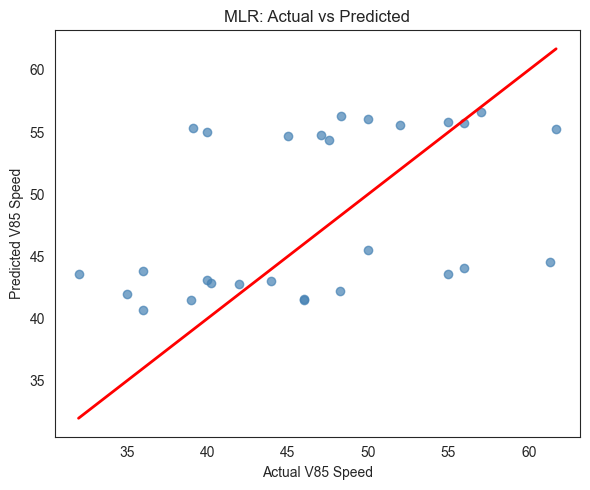

In [36]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, color="steelblue", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("MLR: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

R2: 0.09125202665547938
RMSE: 7.588691586828396
MAE: 6.219892857142865


In [39]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,Radius of Curve,0.555180
1,Gradient,0.243601
4,Right Shoulder Width,0.075222
3,Left Shoulder Width,0.064787
2,Carriageway Width,0.061210


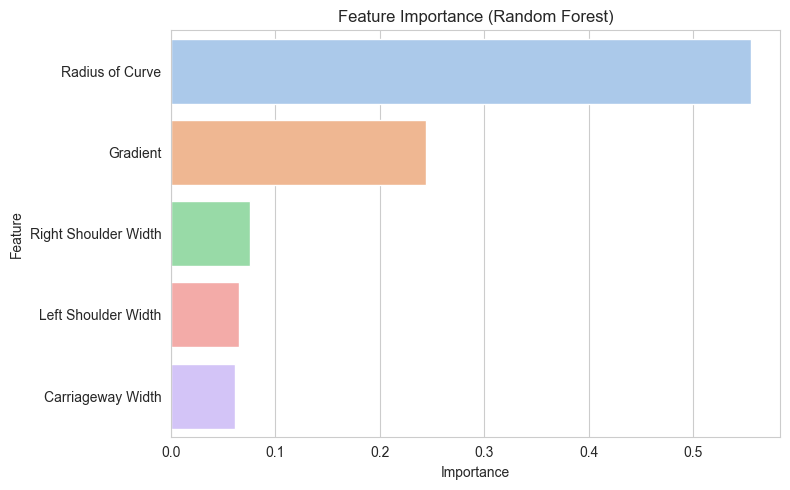

In [40]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance, palette="pastel")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

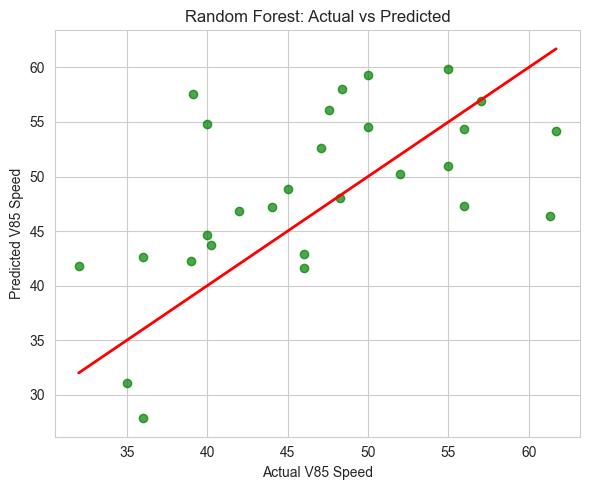

In [41]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_rf, color="green", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [42]:
from sklearn.svm import SVR

# Initialize model
svr_model = SVR()

# Train model
svr_model.fit(X_train, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R2:", r2_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)

R2: 0.13370325493480584
RMSE: 7.409322810637845
MAE: 6.11248661904324


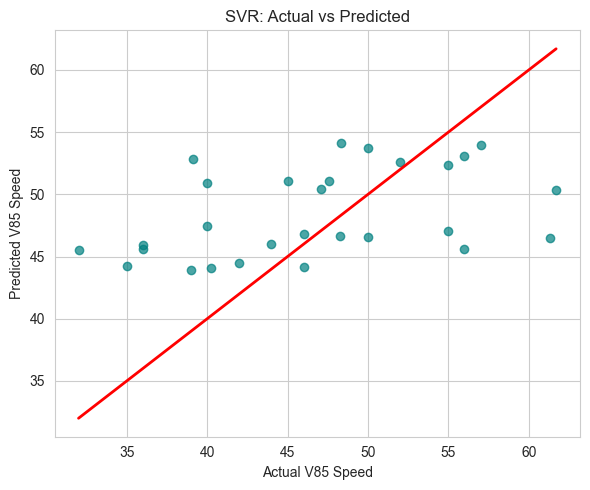

In [44]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_svr, color="teal", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [45]:
from xgboost import XGBRegressor

# Initialize model
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

In [46]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)

R2: -0.22655175007125194
RMSE: 8.816335599684413
MAE: 7.153053910391672


In [47]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
0,Radius of Curve,0.439845
4,Right Shoulder Width,0.197977
1,Gradient,0.123229
2,Carriageway Width,0.122794
3,Left Shoulder Width,0.116156


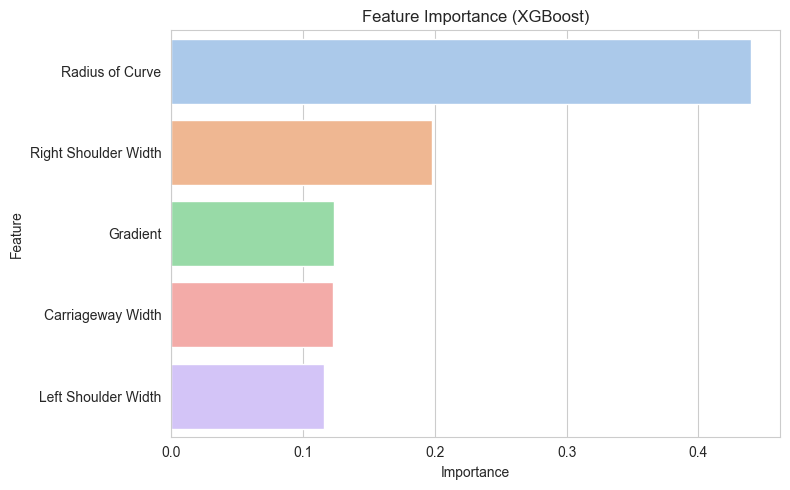

In [48]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=xgb_importance, palette="pastel")

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

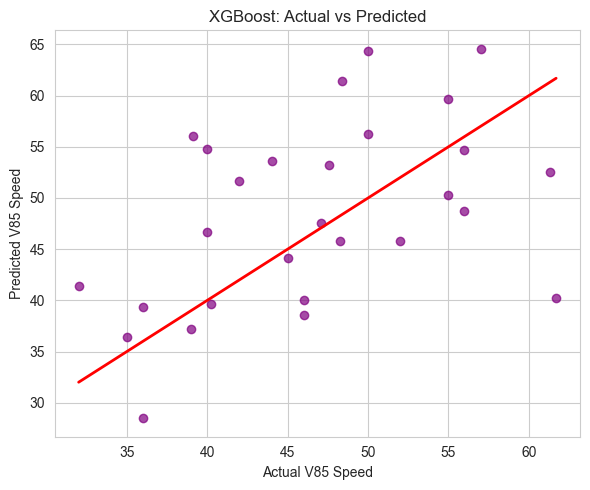

In [49]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_xgb, color="purple", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [50]:
from sklearn.neural_network import MLPRegressor

# Initialize model
ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

# Train model
ann_model.fit(X_train, y_train)

# Predict
y_pred_ann = ann_model.predict(X_test)

In [51]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print("R2:", r2_ann)
print("RMSE:", rmse_ann)
print("MAE:", mae_ann)

R2: -4.345119606385297
RMSE: 18.404494313893338
MAE: 14.070907387103714


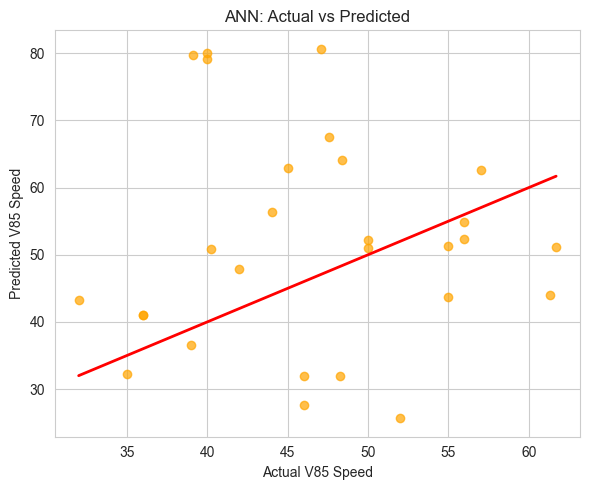

In [52]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_ann, color="orange", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("ANN: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [53]:
base_model_results = pd.DataFrame({
    "Model": ["MLR", "Random Forest", "SVR", "XGBoost", "ANN"],
    "R2": [r2, r2_rf, r2_svr, r2_xgb, r2_ann],
    "RMSE": [rmse, rmse_rf, rmse_svr, rmse_xgb, rmse_ann],
    "MAE": [mae, mae_rf, mae_svr, mae_xgb, mae_ann]
})

base_model_results.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
2,SVR,0.133703,7.409323,6.112487
1,Random Forest,0.091252,7.588692,6.219893
0,MLR,-0.002315,7.969796,6.472600
3,XGBoost,-0.226552,8.816336,7.153054
4,ANN,-4.345120,18.404494,14.070907


In [54]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [55]:
rf_tuned = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [56]:
rf_tuned.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

In [57]:
y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test)

In [58]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("R2:", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)

R2: 0.3436113734194197
RMSE: 6.449494829946649
MAE: 4.859280752035744


In [59]:
importance_tuned = pd.DataFrame({
    "Feature": features,
    "Importance": rf_tuned.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_tuned

,Feature,Importance
0,Radius of Curve,0.563170
1,Gradient,0.244994
4,Right Shoulder Width,0.076270
2,Carriageway Width,0.058569
3,Left Shoulder Width,0.056997


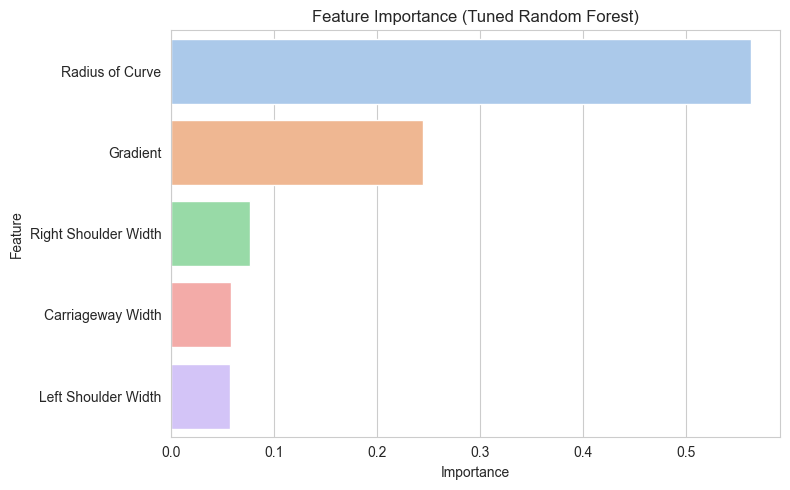

In [60]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_tuned,
    palette="pastel"
)

plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

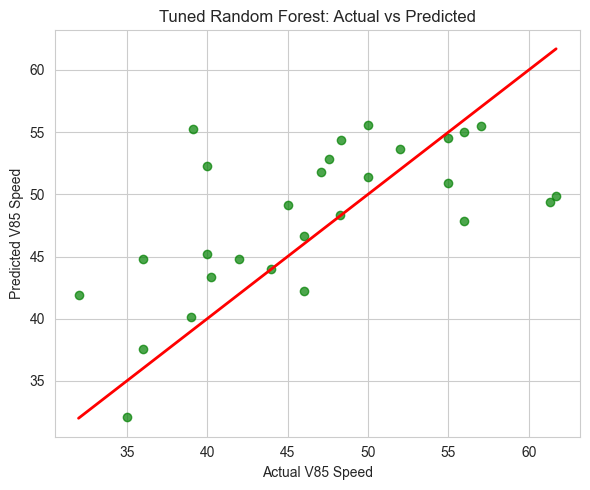

In [61]:
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    y_pred_rf_tuned,
    color="green",
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [62]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

In [63]:
svr_tuned = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    verbose=1,
    n_jobs=-1
)

svr_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [64]:
svr_tuned.best_params_

{'C': 1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}

In [65]:
y_pred_svr_tuned = svr_tuned.best_estimator_.predict(X_test)

In [66]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("R2:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("MAE:", mae_svr_tuned)

R2: -0.12660685113096526
RMSE: 8.449506984141474
MAE: 6.897824469797229


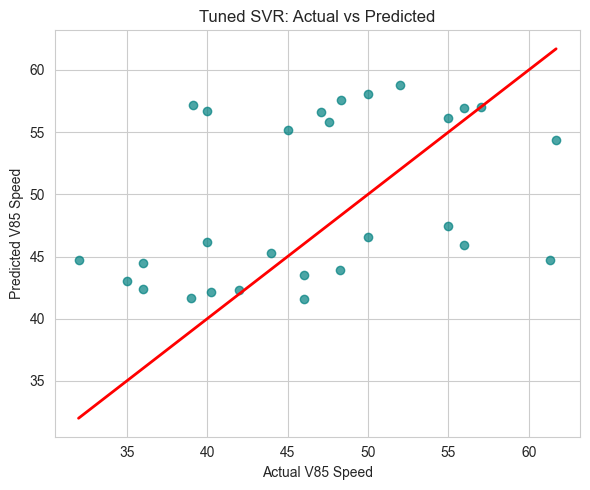

In [67]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_svr_tuned, color="teal", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned SVR: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [68]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [69]:
from xgboost import XGBRegressor

xgb_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [70]:
xgb_tuned.best_params_

{'subsample': 0.7,
 'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.01,
 'colsample_bytree': 0.7}

In [71]:
y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test)

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("R2:", r2_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("MAE:", mae_xgb_tuned)

R2: 0.22683144192324511
RMSE: 6.99974578291646
MAE: 5.2020821707589295


In [73]:
xgb_importance_tuned = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_tuned.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance_tuned

,Feature,Importance
0,Radius of Curve,0.475179
1,Gradient,0.169115
4,Right Shoulder Width,0.145132
2,Carriageway Width,0.106253
3,Left Shoulder Width,0.104321


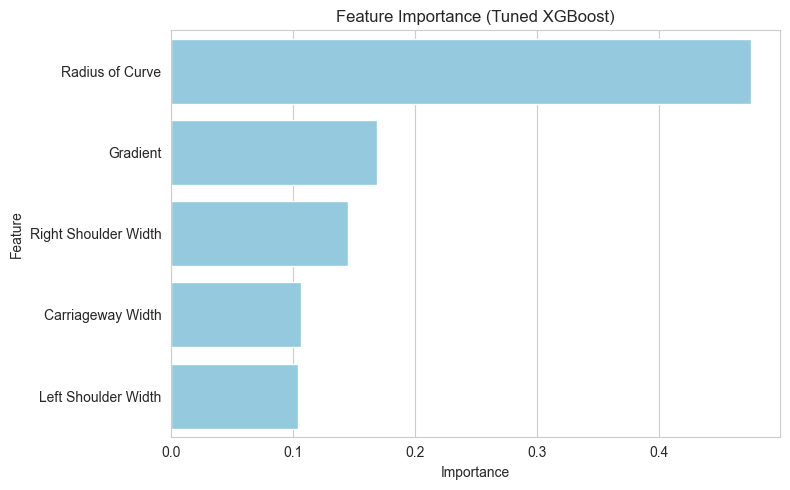

In [74]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance_tuned,
    color="skyblue"
)

plt.title("Feature Importance (Tuned XGBoost)")
plt.tight_layout()
plt.show()

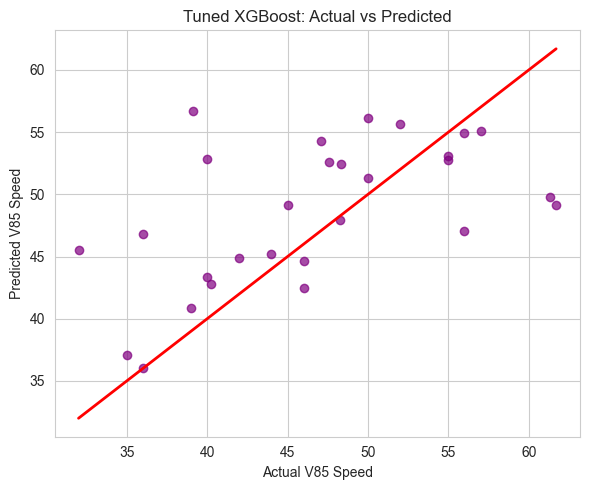

In [75]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_xgb_tuned, color="purple", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor

param_grid_ann = {
    "hidden_layer_sizes": [(32,), (64,), (32, 16), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "solver": ["adam"],
    "max_iter": [3000, 5000]
}

In [77]:
ann_tuned = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=42),
    param_distributions=param_grid_ann,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ann_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(32,), (64,), ...], 'learning_rate_init': [0.001, 0.01], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [78]:
ann_tuned.best_params_

{'solver': 'adam',
 'max_iter': 3000,
 'learning_rate_init': 0.001,
 'hidden_layer_sizes': (32,),
 'alpha': 0.01,
 'activation': 'tanh'}

In [79]:
y_pred_ann_tuned = ann_tuned.best_estimator_.predict(X_test)

In [80]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_ann_tuned = r2_score(y_test, y_pred_ann_tuned)
rmse_ann_tuned = np.sqrt(mean_squared_error(y_test, y_pred_ann_tuned))
mae_ann_tuned = mean_absolute_error(y_test, y_pred_ann_tuned)

print("R2:", r2_ann_tuned)
print("RMSE:", rmse_ann_tuned)
print("MAE:", mae_ann_tuned)

R2: 0.017085813030900288
RMSE: 7.892288948917734
MAE: 6.444285390397261


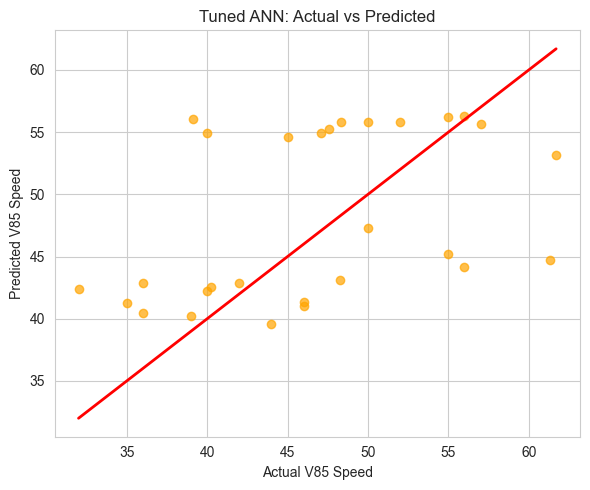

In [81]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_ann_tuned, color="orange", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned ANN: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [82]:
base_models = pd.DataFrame({
    "Model": ["MLR", "SVR", "Random Forest", "XGBoost", "ANN"],
    "R2": [r2, r2_svr, r2_rf, r2_xgb, r2_ann],
    "RMSE": [rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann],
    "MAE": [mae, mae_svr, mae_rf, mae_xgb, mae_ann]
})

base_models = base_models.sort_values(by="R2", ascending=False)
base_models

,Model,R2,RMSE,MAE
1,SVR,0.133703,7.409323,6.112487
2,Random Forest,0.091252,7.588692,6.219893
0,MLR,-0.002315,7.969796,6.472600
3,XGBoost,-0.226552,8.816336,7.153054
4,ANN,-4.345120,18.404494,14.070907


In [83]:
tuned_models = pd.DataFrame({
    "Model": ["Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],
    "R2": [r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned],
    "RMSE": [rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned],
    "MAE": [mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned]
})

tuned_models = tuned_models.sort_values(by="R2", ascending=False)
tuned_models

,Model,R2,RMSE,MAE
0,Tuned RF,0.343611,6.449495,4.859281
2,Tuned XGBoost,0.226831,6.999746,5.202082
3,Tuned ANN,0.017086,7.892289,6.444285
1,Tuned SVR,-0.126607,8.449507,6.897824


In [84]:
final_comparison = pd.DataFrame({
    "Model": ["MLR", "SVR", "RF", "XGBoost", "ANN",
              "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],

    "R2": [r2, r2_svr, r2_rf, r2_xgb, r2_ann,
           r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned],

    "RMSE": [rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann,
             rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned],

    "MAE": [mae, mae_svr, mae_rf, mae_xgb, mae_ann,
            mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned]
})

final_comparison = final_comparison.sort_values(by="R2", ascending=False)
final_comparison

,Model,R2,RMSE,MAE
5,Tuned RF,0.343611,6.449495,4.859281
7,Tuned XGBoost,0.226831,6.999746,5.202082
1,SVR,0.133703,7.409323,6.112487
2,RF,0.091252,7.588692,6.219893
8,Tuned ANN,0.017086,7.892289,6.444285
0,MLR,-0.002315,7.969796,6.472600
6,Tuned SVR,-0.126607,8.449507,6.897824
3,XGBoost,-0.226552,8.816336,7.153054
4,ANN,-4.345120,18.404494,14.070907


In [85]:
model_rf = rf_tuned.best_estimator_
model_xgb = xgb_tuned.best_estimator_

In [86]:
from sklearn.model_selection import cross_val_score
import numpy as np

# ---- RANDOM FOREST ----
cv_r2_rf = cross_val_score(model_rf, X_scaled, y, cv=5, scoring="r2")
cv_rmse_rf = np.sqrt(-cross_val_score(model_rf, X_scaled, y, cv=5, scoring="neg_mean_squared_error"))
cv_mae_rf = -cross_val_score(model_rf, X_scaled, y, cv=5, scoring="neg_mean_absolute_error")

# ---- XGBOOST ----
cv_r2_xgb = cross_val_score(model_xgb, X_scaled, y, cv=5, scoring="r2")
cv_rmse_xgb = np.sqrt(-cross_val_score(model_xgb, X_scaled, y, cv=5, scoring="neg_mean_squared_error"))
cv_mae_xgb = -cross_val_score(model_xgb, X_scaled, y, cv=5, scoring="neg_mean_absolute_error")

In [87]:
print("===== Tuned RF CV Results =====")
print("R2:", cv_r2_rf)
print("Mean R2:", np.mean(cv_r2_rf))
print("RMSE:", cv_rmse_rf)
print("Mean RMSE:", np.mean(cv_rmse_rf))
print("MAE:", cv_mae_rf)
print("Mean MAE:", np.mean(cv_mae_rf))

print("\n===== Tuned XGBoost CV Results =====")
print("R2:", cv_r2_xgb)
print("Mean R2:", np.mean(cv_r2_xgb))
print("RMSE:", cv_rmse_xgb)
print("Mean RMSE:", np.mean(cv_rmse_xgb))
print("MAE:", cv_mae_xgb)
print("Mean MAE:", np.mean(cv_mae_xgb))

===== Tuned RF CV Results =====
R2: [ 0.3961748   0.33522055  0.46198113  0.51882308 -0.09798968]
Mean R2: 0.32284197646394586
RMSE: [ 8.03527809  6.35018764  6.90793234  8.42111244 11.47416713]
Mean RMSE: 8.237735529279423
MAE: [6.26791518 4.78568105 5.66882747 6.70352817 8.9720585 ]
Mean MAE: 6.479602074164302

===== Tuned XGBoost CV Results =====
R2: [ 0.41273601  0.185153    0.43584123  0.50485465 -0.09230681]
Mean R2: 0.2892556160914158
RMSE: [ 7.92431959  7.03049338  7.0737546   8.54246926 11.44443516]
Mean RMSE: 8.403094395894929
MAE: [6.04801361 5.33778981 5.83361792 6.76860755 9.06968749]
Mean MAE: 6.611543273925781


In [88]:
cv_comparison = pd.DataFrame({
    "Model": ["Tuned RF", "Tuned XGBoost"],
    "Mean R2": [np.mean(cv_r2_rf), np.mean(cv_r2_xgb)],
    "Mean RMSE": [np.mean(cv_rmse_rf), np.mean(cv_rmse_xgb)],
    "Mean MAE": [np.mean(cv_mae_rf), np.mean(cv_mae_xgb)]
})

cv_comparison

,Model,Mean R2,Mean RMSE,Mean MAE
0,Tuned RF,0.322842,8.237736,6.479602
1,Tuned XGBoost,0.289256,8.403094,6.611543


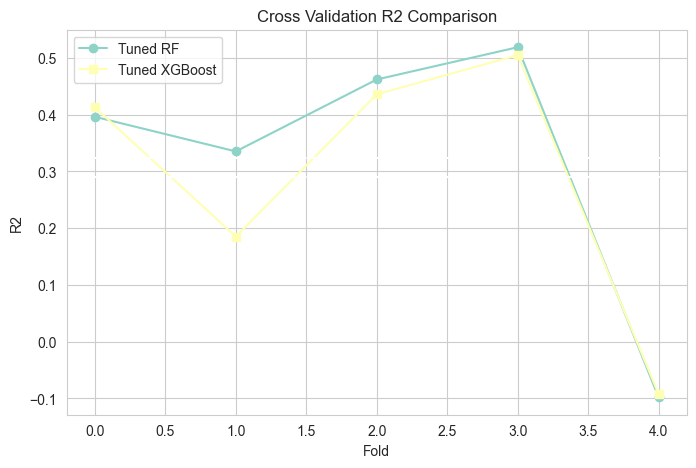

In [89]:
plt.figure(figsize=(8,5))

plt.plot(cv_r2_rf, marker='o', label="Tuned RF")
plt.plot(cv_r2_xgb, marker='s', label="Tuned XGBoost")

plt.axhline(np.mean(cv_r2_rf), linestyle='--')
plt.axhline(np.mean(cv_r2_xgb), linestyle='--')

plt.title("Cross Validation R2 Comparison")
plt.xlabel("Fold")
plt.ylabel("R2")
plt.legend()

plt.show()

AVERAGE SHOULDER WIDTH

In [90]:
df["Avg Shoulder Width"] = (
    df["Left Shoulder Width"] + df["Right Shoulder Width"]
) / 2

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    140 non-null    int64  
 1   V85 Speed             140 non-null    float64
 2   Gradient              140 non-null    float64
 3   Radius of Curve       140 non-null    int64  
 4   Carriageway Width     140 non-null    float64
 5   Left Shoulder Width   140 non-null    float64
 6   Left Shoulder Type    140 non-null    str    
 7   Right Shoulder Width  140 non-null    float64
 8   Right Shoulder Type   140 non-null    str    
 9   Avg Shoulder Width    140 non-null    float64
dtypes: float64(6), int64(2), str(2)
memory usage: 11.1 KB


In [92]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,Avg Shoulder Width
0,1,57.0,1.27,1500,5.5,0.9,Gravel,0.9,Gravel,0.9
1,2,33.0,2.92,46,5.5,0.9,Gravel,0.9,Gravel,0.9
2,3,43.0,7.97,1500,5.5,0.9,Gravel,0.9,Gravel,0.9
3,4,48.0,2.07,1500,5.5,0.9,Gravel,0.9,Gravel,0.9
4,5,36.0,1.21,16,5.5,0.9,Gravel,0.9,Gravel,0.9


In [93]:
features_avg = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Avg Shoulder Width"
]

target = "V85 Speed"

X_avg = df[features_avg]
y = df[target]

In [94]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_avg = StandardScaler()
X_avg_scaled = scaler_avg.fit_transform(X_avg)
X_avg_scaled = pd.DataFrame(X_avg_scaled, columns=X_avg.columns)
X_avg_scaled.head()

,Radius of Curve,Gradient,Carriageway Width,Avg Shoulder Width
0,1.399280,-1.014691,-0.811857,1.183635
1,-0.782112,-0.371273,-0.811857,1.183635
2,1.399280,1.597976,-0.811857,1.183635
3,1.399280,-0.702731,-0.811857,1.183635
4,-0.827120,-1.038088,-0.811857,1.183635


In [95]:
from sklearn.model_selection import train_test_split

X_train_avg, X_test_avg, y_train_avg, y_test_avg = train_test_split(
    X_avg_scaled, y, test_size=0.2, random_state=42
)

In [96]:
from IPython.display import display

display(X_train_avg)
display(X_test_avg)
display(y_train_avg)
display(y_test_avg)

,Radius of Curve,Gradient,Carriageway Width,Avg Shoulder Width
16,1.399280,-1.119978,-1.562039,-0.669069
18,-0.731103,0.361834,-0.807570,-0.452920
10,1.399280,1.804650,-0.811857,1.183635
111,1.399280,-0.437565,1.331518,-0.823461
101,-0.708599,1.631122,0.795675,-0.823461
...,...,...,...,...
71,-0.783612,0.303341,0.795675,1.492419
106,-0.581076,1.141734,0.795675,-0.823461
14,1.399280,-1.119978,1.331518,0.288162
92,-0.551070,0.872669,0.795675,-0.823461


,Radius of Curve,Gradient,Carriageway Width,Avg Shoulder Width
108,1.399280,-0.269886,0.795675,-0.823461
67,-0.776111,-1.420240,0.795675,1.492419
31,-0.783612,0.829774,-0.958678,-0.483798
119,-0.798615,1.149533,0.795675,-0.823461
42,-0.821119,-0.145102,-1.356274,-0.699947
12,1.399280,-1.314953,1.331518,0.396236
81,-0.671092,0.244848,0.795675,-0.823461
69,-0.671092,-1.201868,0.795675,1.492419
104,-0.521065,-1.303255,-0.276013,-0.823461
109,-0.476057,0.786880,0.795675,-0.823461


16     60.00
18     43.00
10     49.55
111    57.00
101    44.10
       ...  
71     31.25
106    51.55
14     58.20
92     58.00
102    60.00
Name: V85 Speed, Length: 112, dtype: float64

108    50.00
67     46.00
31     40.25
119    36.00
42     35.00
12     39.10
81     56.00
69     48.25
104    55.00
109    50.00
113    48.35
56     46.00
66     47.55
19     40.00
132    61.30
78     61.70
11     40.00
27     47.10
127    56.00
110    57.00
36     42.00
118    52.00
60     45.00
4      36.00
131    55.00
26     39.00
138    44.00
96     32.00
Name: V85 Speed, dtype: float64

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

mlr_avg = LinearRegression()
mlr_avg.fit(X_train_avg, y_train_avg)

y_pred_mlr_avg = mlr_avg.predict(X_test_avg)

r2_mlr_avg = r2_score(y_test_avg, y_pred_mlr_avg)
rmse_mlr_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_mlr_avg))
mae_mlr_avg = mean_absolute_error(y_test_avg, y_pred_mlr_avg)

print("R2:", r2_mlr_avg)
print("RMSE:", rmse_mlr_avg)
print("MAE:", mae_mlr_avg)

R2: -0.003735782461604442
RMSE: 7.975444159654604
MAE: 6.489084823042101


In [98]:
coefficients_avg = pd.DataFrame({
    "Variable": features_avg,
    "Coefficient": mlr_avg.coef_
})

coefficients_avg

,Variable,Coefficient
0,Radius of Curve,5.872721
1,Gradient,0.491361
2,Carriageway Width,0.549516
3,Avg Shoulder Width,-0.551055


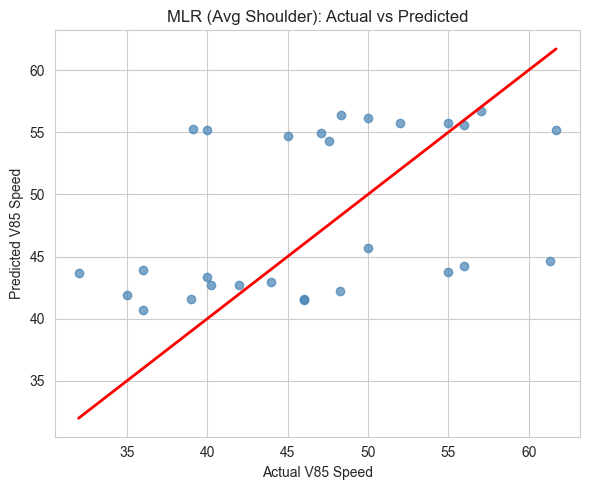

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_mlr_avg, color="steelblue", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("MLR (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [100]:
from sklearn.ensemble import RandomForestRegressor

rf_avg = RandomForestRegressor(random_state=42)
rf_avg.fit(X_train_avg, y_train_avg)

y_pred_rf_avg = rf_avg.predict(X_test_avg)

r2_rf_avg = r2_score(y_test_avg, y_pred_rf_avg)
rmse_rf_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_rf_avg))
mae_rf_avg = mean_absolute_error(y_test_avg, y_pred_rf_avg)

print("R2:", r2_rf_avg)
print("RMSE:", rmse_rf_avg)
print("MAE:", mae_rf_avg)

R2: 0.010954636047373345
RMSE: 7.916865761280975
MAE: 6.49217857142858


In [101]:
importance_rf_avg = pd.DataFrame({
    "Feature": features_avg,
    "Importance": rf_avg.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_rf_avg

,Feature,Importance
0,Radius of Curve,0.565211
1,Gradient,0.259413
3,Avg Shoulder Width,0.121393
2,Carriageway Width,0.053984


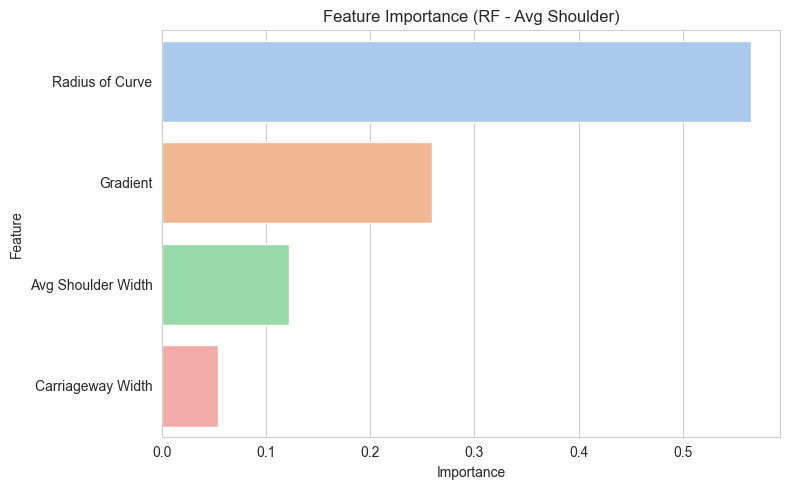

In [102]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_rf_avg, palette="pastel")
plt.title("Feature Importance (RF - Avg Shoulder)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

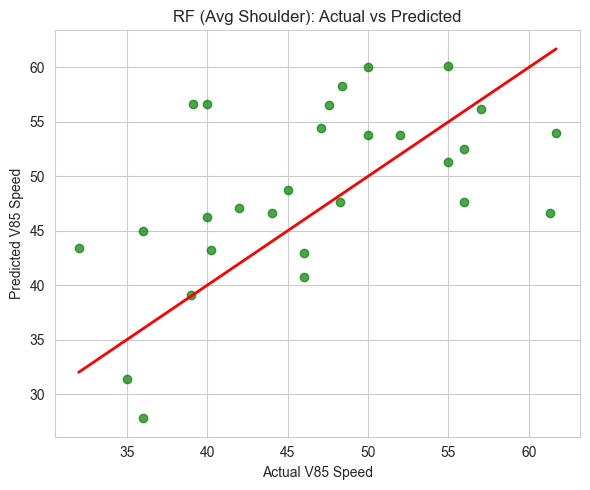

In [103]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_rf_avg, color="green", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("RF (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [104]:
from sklearn.svm import SVR

svr_avg = SVR()
svr_avg.fit(X_train_avg, y_train_avg)

y_pred_svr_avg = svr_avg.predict(X_test_avg)

r2_svr_avg = r2_score(y_test_avg, y_pred_svr_avg)
rmse_svr_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_svr_avg))
mae_svr_avg = mean_absolute_error(y_test_avg, y_pred_svr_avg)

print("R2:", r2_svr_avg)
print("RMSE:", rmse_svr_avg)
print("MAE:", mae_svr_avg)

R2: 0.09668223692962119
RMSE: 7.565984556615773
MAE: 6.268296132978945


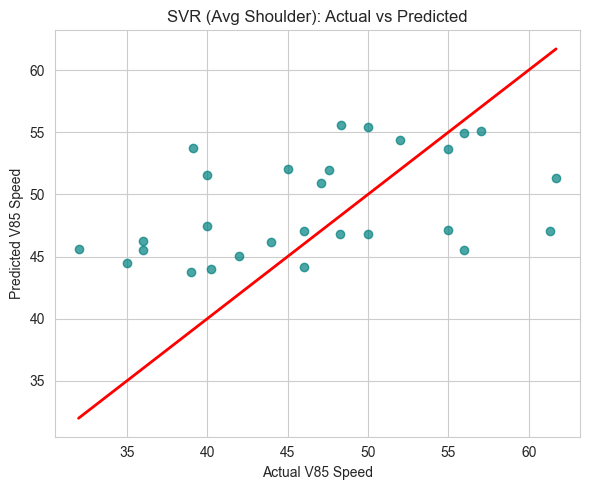

In [105]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_svr_avg, color="teal", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [106]:
from xgboost import XGBRegressor

xgb_avg = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb_avg.fit(X_train_avg, y_train_avg)

y_pred_xgb_avg = xgb_avg.predict(X_test_avg)

r2_xgb_avg = r2_score(y_test_avg, y_pred_xgb_avg)
rmse_xgb_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_xgb_avg))
mae_xgb_avg = mean_absolute_error(y_test_avg, y_pred_xgb_avg)

print("R2:", r2_xgb_avg)
print("RMSE:", rmse_xgb_avg)
print("MAE:", mae_xgb_avg)

R2: -0.3916340926654429
RMSE: 9.390910578067396
MAE: 7.56213380268642


In [107]:
importance_xgb_avg = pd.DataFrame({
    "Feature": features_avg,
    "Importance": xgb_avg.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_xgb_avg

,Feature,Importance
0,Radius of Curve,0.442446
3,Avg Shoulder Width,0.288186
1,Gradient,0.138163
2,Carriageway Width,0.131205


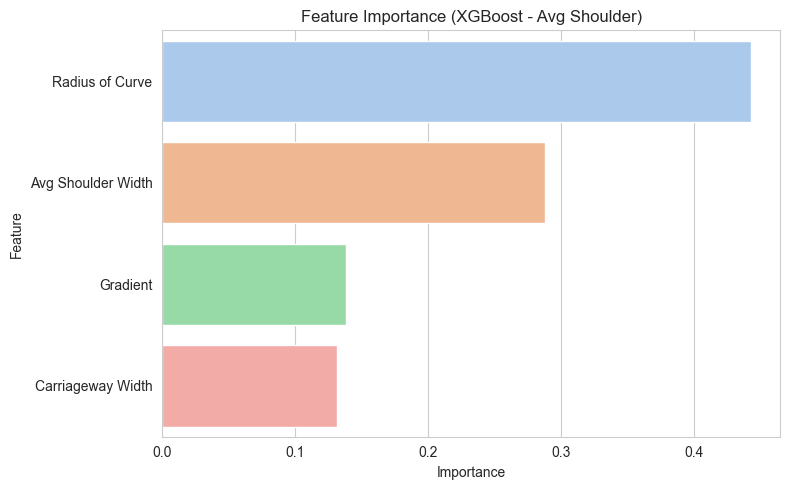

In [108]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_xgb_avg, palette="pastel")
plt.title("Feature Importance (XGBoost - Avg Shoulder)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

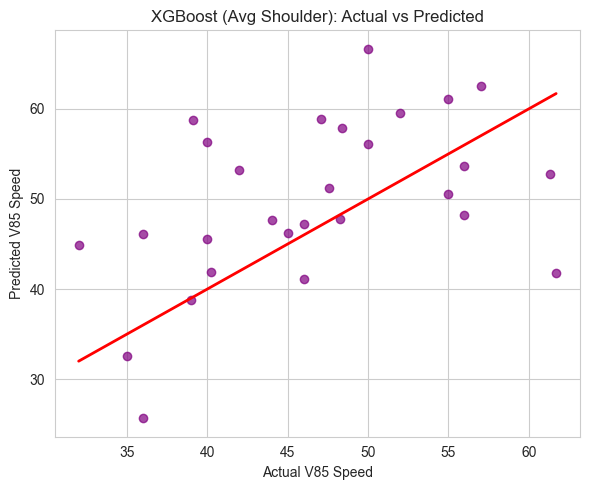

In [109]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_xgb_avg, color="purple", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [110]:
from sklearn.neural_network import MLPRegressor

ann_avg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

ann_avg.fit(X_train_avg, y_train_avg)

y_pred_ann_avg = ann_avg.predict(X_test_avg)

r2_ann_avg = r2_score(y_test_avg, y_pred_ann_avg)
rmse_ann_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_ann_avg))
mae_ann_avg = mean_absolute_error(y_test_avg, y_pred_ann_avg)

print("R2:", r2_ann_avg)
print("RMSE:", rmse_ann_avg)
print("MAE:", mae_ann_avg)

R2: -0.8487383331613019
RMSE: 10.823878247501412
MAE: 8.698773353590765


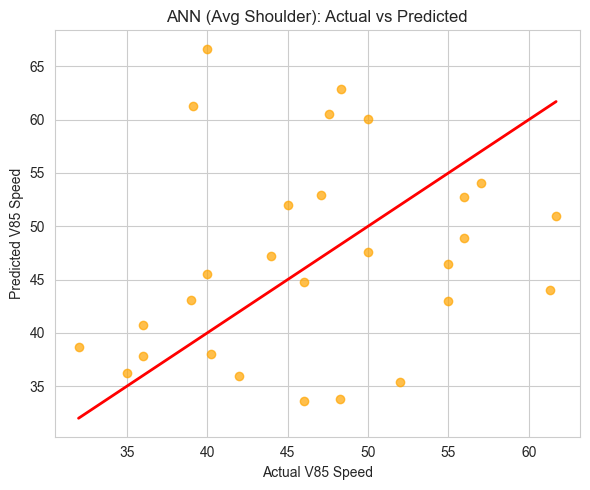

In [111]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_ann_avg, color="orange", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("ANN (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [112]:
base_models_avg = pd.DataFrame({
    "Model": ["MLR", "Random Forest", "SVR", "XGBoost", "ANN"],
    "R2": [r2_mlr_avg, r2_rf_avg, r2_svr_avg, r2_xgb_avg, r2_ann_avg],
    "RMSE": [rmse_mlr_avg, rmse_rf_avg, rmse_svr_avg, rmse_xgb_avg, rmse_ann_avg],
    "MAE": [mae_mlr_avg, mae_rf_avg, mae_svr_avg, mae_xgb_avg, mae_ann_avg]
})

base_models_avg.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
2,SVR,0.096682,7.565985,6.268296
1,Random Forest,0.010955,7.916866,6.492179
0,MLR,-0.003736,7.975444,6.489085
3,XGBoost,-0.391634,9.390911,7.562134
4,ANN,-0.848738,10.823878,8.698773


FOR TUNED MODELS

In [113]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [114]:
rf_tuned_avg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_tuned_avg.fit(X_train_avg, y_train_avg)
rf_tuned_avg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 5}

In [115]:
y_pred_rf_tuned_avg = rf_tuned_avg.best_estimator_.predict(X_test_avg)

r2_rf_tuned_avg = r2_score(y_test_avg, y_pred_rf_tuned_avg)
rmse_rf_tuned_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_rf_tuned_avg))
mae_rf_tuned_avg = mean_absolute_error(y_test_avg, y_pred_rf_tuned_avg)

print("R2:", r2_rf_tuned_avg)
print("RMSE:", rmse_rf_tuned_avg)
print("MAE:", mae_rf_tuned_avg)

R2: 0.2801252965611344
RMSE: 6.754195569765775
MAE: 5.216991625223836


In [116]:
importance_rf_tuned_avg = pd.DataFrame({
    "Feature": features_avg,
    "Importance": rf_tuned_avg.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_rf_tuned_avg

,Feature,Importance
0,Radius of Curve,0.599206
1,Gradient,0.230019
3,Avg Shoulder Width,0.101980
2,Carriageway Width,0.068794


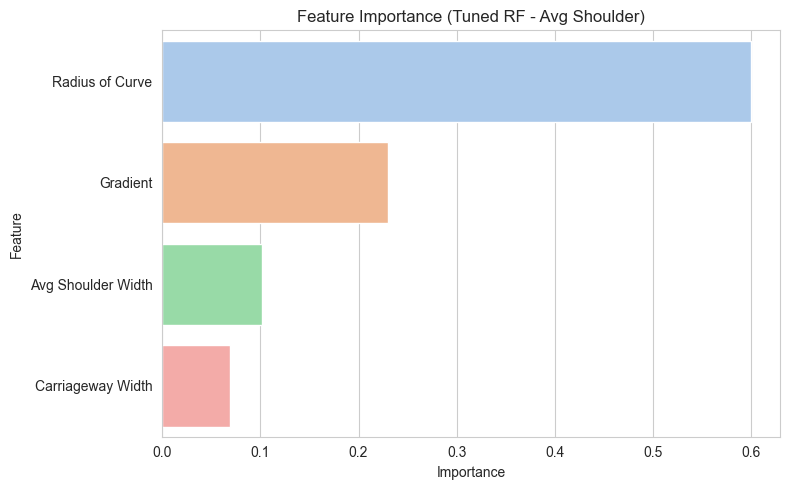

In [117]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_rf_tuned_avg, palette="pastel")
plt.title("Feature Importance (Tuned RF - Avg Shoulder)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

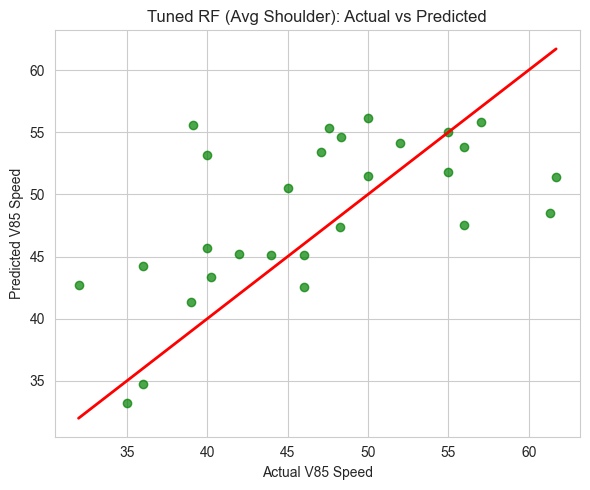

In [118]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_rf_tuned_avg, color="green", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned RF (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [119]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

In [120]:
svr_tuned_avg = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    verbose=1,
    n_jobs=-1
)

svr_tuned_avg.fit(X_train_avg, y_train_avg)
svr_tuned_avg.best_params_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


{'C': 1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}

In [121]:
y_pred_svr_tuned_avg = svr_tuned_avg.best_estimator_.predict(X_test_avg)

r2_svr_tuned_avg = r2_score(y_test_avg, y_pred_svr_tuned_avg)
rmse_svr_tuned_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_svr_tuned_avg))
mae_svr_tuned_avg = mean_absolute_error(y_test_avg, y_pred_svr_tuned_avg)

print("R2:", r2_svr_tuned_avg)
print("RMSE:", rmse_svr_tuned_avg)
print("MAE:", mae_svr_tuned_avg)

R2: -0.0634535036182815
RMSE: 8.20926789811948
MAE: 6.741997824750709


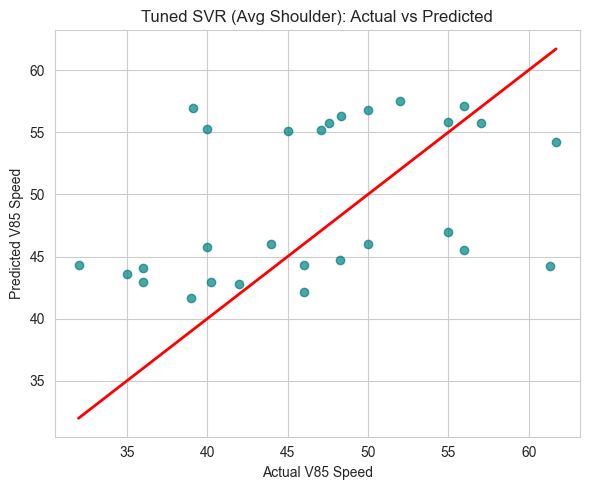

In [122]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_svr_tuned_avg, color="teal", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned SVR (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [123]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [124]:
xgb_tuned_avg = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_tuned_avg.fit(X_train_avg, y_train_avg)
xgb_tuned_avg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'subsample': 0.7,
 'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.01,
 'colsample_bytree': 0.7}

In [125]:
y_pred_xgb_tuned_avg = xgb_tuned_avg.best_estimator_.predict(X_test_avg)

r2_xgb_tuned_avg = r2_score(y_test_avg, y_pred_xgb_tuned_avg)
rmse_xgb_tuned_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_xgb_tuned_avg))
mae_xgb_tuned_avg = mean_absolute_error(y_test_avg, y_pred_xgb_tuned_avg)

print("R2:", r2_xgb_tuned_avg)
print("RMSE:", rmse_xgb_tuned_avg)
print("MAE:", mae_xgb_tuned_avg)

R2: 0.22021250065401
RMSE: 7.029643643173445
MAE: 5.422647149222239


In [126]:
importance_xgb_tuned_avg = pd.DataFrame({
    "Feature": features_avg,
    "Importance": xgb_tuned_avg.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_xgb_tuned_avg

,Feature,Importance
0,Radius of Curve,0.571179
1,Gradient,0.192694
3,Avg Shoulder Width,0.129238
2,Carriageway Width,0.106889


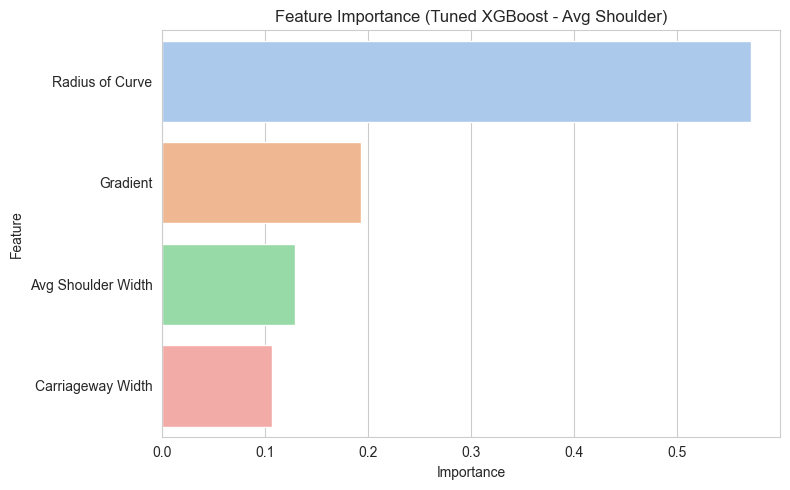

In [127]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_xgb_tuned_avg, palette="pastel")
plt.title("Feature Importance (Tuned XGBoost - Avg Shoulder)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

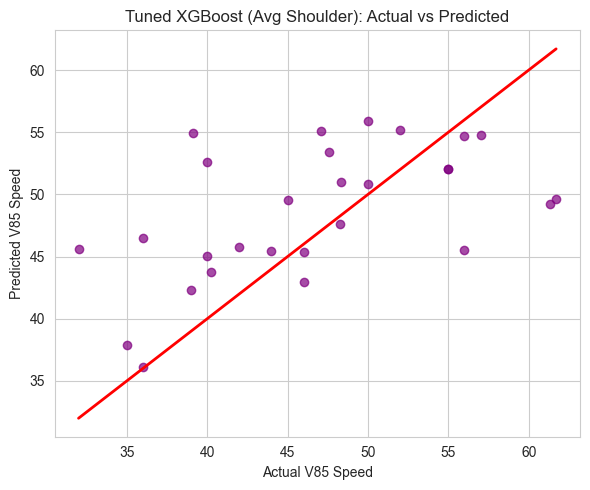

In [128]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_xgb_tuned_avg, color="purple", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned XGBoost (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [129]:
param_grid_ann = {
    "hidden_layer_sizes": [(32,), (64,), (32, 16), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "solver": ["adam"],
    "max_iter": [3000, 5000]
}

In [130]:
ann_tuned_avg = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=42),
    param_distributions=param_grid_ann,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ann_tuned_avg.fit(X_train_avg, y_train_avg)
ann_tuned_avg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'adam',
 'max_iter': 5000,
 'learning_rate_init': 0.001,
 'hidden_layer_sizes': (32, 16),
 'alpha': 0.001,
 'activation': 'tanh'}

In [131]:
y_pred_ann_tuned_avg = ann_tuned_avg.best_estimator_.predict(X_test_avg)

r2_ann_tuned_avg = r2_score(y_test_avg, y_pred_ann_tuned_avg)
rmse_ann_tuned_avg = np.sqrt(mean_squared_error(y_test_avg, y_pred_ann_tuned_avg))
mae_ann_tuned_avg = mean_absolute_error(y_test_avg, y_pred_ann_tuned_avg)

print("R2:", r2_ann_tuned_avg)
print("RMSE:", rmse_ann_tuned_avg)
print("MAE:", mae_ann_tuned_avg)

R2: 0.4261293575088939
RMSE: 6.0304841362725785
MAE: 4.721809609231492


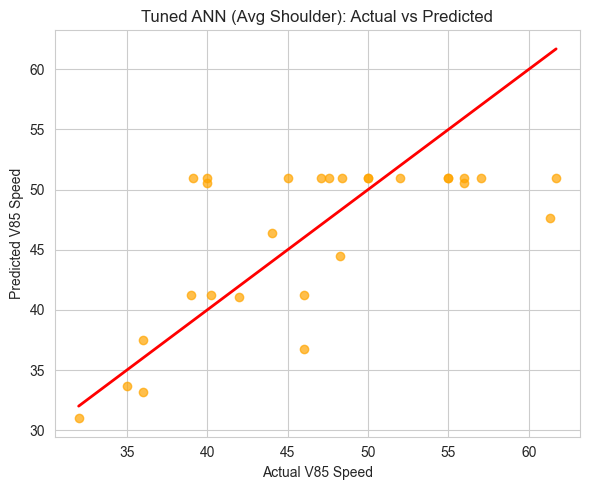

In [132]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_avg, y_pred_ann_tuned_avg, color="orange", alpha=0.7)

plt.plot(
    [y_test_avg.min(), y_test_avg.max()],
    [y_test_avg.min(), y_test_avg.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned ANN (Avg Shoulder): Actual vs Predicted")
plt.tight_layout()
plt.show()

In [133]:
tuned_models_avg = pd.DataFrame({
    "Model": ["Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],
    "R2": [r2_rf_tuned_avg, r2_svr_tuned_avg, r2_xgb_tuned_avg, r2_ann_tuned_avg],
    "RMSE": [rmse_rf_tuned_avg, rmse_svr_tuned_avg, rmse_xgb_tuned_avg, rmse_ann_tuned_avg],
    "MAE": [mae_rf_tuned_avg, mae_svr_tuned_avg, mae_xgb_tuned_avg, mae_ann_tuned_avg]
})

tuned_models_avg.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
3,Tuned ANN,0.426129,6.030484,4.721810
0,Tuned RF,0.280125,6.754196,5.216992
2,Tuned XGBoost,0.220213,7.029644,5.422647
1,Tuned SVR,-0.063454,8.209268,6.741998


In [134]:
final_comparison_avg = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "RF", "XGBoost", "ANN",
        "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"
    ],
    "R2": [
        r2_mlr_avg, r2_svr_avg, r2_rf_avg, r2_xgb_avg, r2_ann_avg,
        r2_rf_tuned_avg, r2_svr_tuned_avg, r2_xgb_tuned_avg, r2_ann_tuned_avg
    ],
    "RMSE": [
        rmse_mlr_avg, rmse_svr_avg, rmse_rf_avg, rmse_xgb_avg, rmse_ann_avg,
        rmse_rf_tuned_avg, rmse_svr_tuned_avg, rmse_xgb_tuned_avg, rmse_ann_tuned_avg
    ],
    "MAE": [
        mae_mlr_avg, mae_svr_avg, mae_rf_avg, mae_xgb_avg, mae_ann_avg,
        mae_rf_tuned_avg, mae_svr_tuned_avg, mae_xgb_tuned_avg, mae_ann_tuned_avg
    ]
})

final_comparison_avg.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
8,Tuned ANN,0.426129,6.030484,4.721810
5,Tuned RF,0.280125,6.754196,5.216992
7,Tuned XGBoost,0.220213,7.029644,5.422647
1,SVR,0.096682,7.565985,6.268296
2,RF,0.010955,7.916866,6.492179
0,MLR,-0.003736,7.975444,6.489085
6,Tuned SVR,-0.063454,8.209268,6.741998
3,XGBoost,-0.391634,9.390911,7.562134
4,ANN,-0.848738,10.823878,8.698773


In [135]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_avg = df[[
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Avg Shoulder Width"
]].astype(float)

vif_avg = pd.DataFrame()
vif_avg["Feature"] = X_vif_avg.columns
vif_avg["VIF"] = [
    variance_inflation_factor(X_vif_avg.values, i)
    for i in range(X_vif_avg.shape[1])
]

vif_avg

,Feature,VIF
0,Radius of Curve,1.756485
1,Gradient,2.957896
2,Carriageway Width,6.164040
3,Avg Shoulder Width,3.275472


In [136]:
# Add feature set label
final_comparison["Feature_Set"] = "L+R"
final_comparison_avg["Feature_Set"] = "AVG"

# Combine both tables
master_table = pd.concat([final_comparison, final_comparison_avg], ignore_index=True)

# Optional: add type (Base/Tuned)
master_table["Type"] = master_table["Model"].apply(
    lambda x: "Tuned" if "Tuned" in x else "Base"
)

# Sort by R2
master_table = master_table.sort_values(by="R2", ascending=False)

master_table.round(3)

,Model,R2,RMSE,MAE,Feature_Set,Type
17,Tuned ANN,0.426,6.030,4.722,AVG,Tuned
0,Tuned RF,0.344,6.449,4.859,L+R,Tuned
14,Tuned RF,0.280,6.754,5.217,AVG,Tuned
1,Tuned XGBoost,0.227,7.000,5.202,L+R,Tuned
16,Tuned XGBoost,0.220,7.030,5.423,AVG,Tuned
2,SVR,0.134,7.409,6.112,L+R,Base
10,SVR,0.097,7.566,6.268,AVG,Base
3,RF,0.091,7.589,6.220,L+R,Base
4,Tuned ANN,0.017,7.892,6.444,L+R,Tuned
11,RF,0.011,7.917,6.492,AVG,Base


BOOTSTRAPPING for TUNED ANN

In [137]:
X = X_avg_scaled   # or X_avg (both okay for ANN)
y = df["V85 Speed"]

In [138]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    **ann_tuned_avg.best_params_,
    random_state=42
)

BOOTSTRAPPING LOOP

In [139]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

n_iterations = 100   # you can use 500–1000

r2_list = []
rmse_list = []
mae_list = []

for i in range(n_iterations):

    # Resample dataset (with replacement)
    X_boot, y_boot = resample(X, y, replace=True, random_state=i)

    # Split bootstrap sample
    from sklearn.model_selection import train_test_split
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_boot, y_boot, test_size=0.2, random_state=42
    )

    # Train model
    model.fit(X_train_b, y_train_b)

    # Predict
    y_pred_b = model.predict(X_test_b)

    # Metrics
    r2_list.append(r2_score(y_test_b, y_pred_b))
    rmse_list.append(np.sqrt(mean_squared_error(y_test_b, y_pred_b)))
    mae_list.append(mean_absolute_error(y_test_b, y_pred_b))

In [140]:
print("Bootstrap Results:")

print("Mean R2:", np.mean(r2_list))
print("Mean RMSE:", np.mean(rmse_list))
print("Mean MAE:", np.mean(mae_list))

Bootstrap Results:
Mean R2: 0.3633564618203357
Mean RMSE: 7.988520969410342
Mean MAE: 5.973610081303807


In [141]:
# 95% Confidence Interval
print("\n95% Confidence Intervals:")

print("R2:", np.percentile(r2_list, [2.5, 97.5]))
print("RMSE:", np.percentile(rmse_list, [2.5, 97.5]))
print("MAE:", np.percentile(mae_list, [2.5, 97.5]))


95% Confidence Intervals:
R2: [-0.08083724  0.63450297]
RMSE: [ 5.50421202 10.65241167]
MAE: [4.12834071 8.20175003]


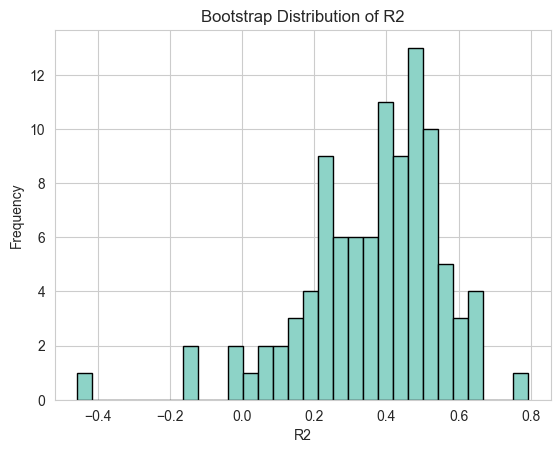

In [142]:
import matplotlib.pyplot as plt

plt.hist(r2_list, bins=30, edgecolor='black')
plt.title("Bootstrap Distribution of R2")
plt.xlabel("R2")
plt.ylabel("Frequency")
plt.show()

In [143]:
results = []

for i in range(n_iterations):

    X_boot, y_boot = resample(X, y, replace=True, random_state=i)

    from sklearn.model_selection import train_test_split
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_boot, y_boot, test_size=0.2, random_state=42
    )

    model.fit(X_train_b, y_train_b)
    y_pred_b = model.predict(X_test_b)

    r2_val = r2_score(y_test_b, y_pred_b)
    rmse_val = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
    mae_val = mean_absolute_error(y_test_b, y_pred_b)

    # store everything
    results.append({
        "iteration": i,
        "r2": r2_val,
        "rmse": rmse_val,
        "mae": mae_val
    })

In [144]:
results_df = pd.DataFrame(results)

In [145]:
best_case = results_df.loc[results_df["r2"].idxmax()]
best_case

iteration    80.000000
r2            0.792758
rmse          4.241994
mae           2.804350
Name: 80, dtype: float64

In [146]:
worst_case = results_df.loc[results_df["r2"].idxmin()]
worst_case

iteration    35.000000
r2           -0.456368
rmse         11.643017
mae           8.363997
Name: 35, dtype: float64

In [147]:
i = int(best_case["iteration"])

X_best, y_best = resample(X, y, replace=True, random_state=i)

In [149]:
best_dataset = X_best.copy()
best_dataset["V85 Speed"] = y_best

best_dataset.head()

,Radius of Curve,Gradient,Carriageway Width,Avg Shoulder Width,V85 Speed
10,1.399280,1.804650,-0.811857,1.183635,49.55
50,1.399280,0.205853,-1.540605,0.689581,43.00
3,1.399280,-0.702731,-0.811857,1.183635,48.00
119,-0.798615,1.149533,0.795675,-0.823461,36.00
15,1.399280,-0.340077,-1.562039,0.720459,46.00
